In [1]:
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# Machine learning
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 120)
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

print("Libraries imported successfully.")


Libraries imported successfully.


In [5]:
DATA_PATH = r"C:\Users\DELL\OneDrive\Documents\global_ecommerce_sales.csv"

df = pd.read_csv(DATA_PATH)

print(f"Dataset shape: {df.shape[0]} rows x {df.shape[1]} columns\n")
print("Column data types:")
print(df.dtypes)
print("\nFirst 5 rows:")
df.head()

Dataset shape: 1200 rows x 7 columns

Column data types:
Order_ID          int64
Country          object
Category         object
Unit_Price      float64
Quantity          int64
Order_Date       object
Total_Amount    float64
dtype: object

First 5 rows:


,Order_ID,Country,Category,Unit_Price,Quantity,Order_Date,Total_Amount
0,1,Germany,Electronics,285.82,7,6/12/2025,2000.74
1,2,Pakistan,Toys,132.00,9,1/14/2025,1188.00
2,3,Australia,Fashion,481.65,9,8/27/2025,4334.85
3,4,UAE,Grocery,244.36,3,3/13/2025,733.08
4,5,Germany,Sports,403.97,5,5/23/2025,2019.85


In [9]:
df.describe()



,Order_ID,Unit_Price,Quantity,Total_Amount
count,1200.000000,1200.000000,1200.000000,1200.000000
mean,600.500000,251.660225,5.006667,1260.210817
std,346.554469,142.792400,2.596904,1050.372560
min,1.000000,5.070000,1.000000,11.140000
25%,300.750000,132.895000,3.000000,392.440000
50%,600.500000,252.755000,5.000000,950.420000
75%,900.250000,375.960000,7.000000,1954.095000
max,1200.000000,499.180000,9.000000,4483.710000


In [8]:
print("Missing Values per column\n")
print(df.isnull().sum())

Missing Values per column

Order_ID        0
Country         0
Category        0
Unit_Price      0
Quantity        0
Order_Date      0
Total_Amount    0
dtype: int64


In [10]:
numeric_cols = ['Unit_Price', 'Quantity', 'Total_Amount']
categorical_cols = ['Country', 'Category']

# Fill numeric gaps with the column median (robust to outliers)
for col in numeric_cols:
    if df[col].isnull().any():
        median_val = df[col].median()
        df[col] = df[col].fillna(median_val)
        print(f"Filled missing values in '{col}' with median: {median_val}")

# Fill categorical gaps with the most frequent value
for col in categorical_cols:
    if df[col].isnull().any():
        mode_val = df[col].mode()[0]
        df[col] = df[col].fillna(mode_val)
        print(f"Filled missing values in '{col}' with mode: {mode_val}")

# Rows with a missing/unparseable Order_Date can't be used for time-based analysis
rows_before = len(df)
df = df.dropna(subset=['Order_Date'])
print(f"Dropped {rows_before - len(df)} rows with missing Order_Date")


Dropped 0 rows with missing Order_Date


In [11]:
duplicate_count = df.duplicated().sum()
print(f"Duplicate rows found: {duplicate_count}")

df = df.drop_duplicates()
print(f"Shape after removing duplicates: {df.shape}")

Duplicate rows found: 0
Shape after removing duplicates: (1200, 7)


In [12]:
for col in categorical_cols:
    df[col] = df[col].astype(str).str.strip()

print("Unique Categories:", sorted(df['Category'].unique()))
print("Unique Countries:", sorted(df['Country'].unique()))


Unique Categories: ['Beauty', 'Books', 'Electronics', 'Fashion', 'Grocery', 'Home Decor', 'Sports', 'Toys']
Unique Countries: ['Australia', 'Brazil', 'Canada', 'China', 'Germany', 'India', 'Pakistan', 'UAE', 'UK', 'USA']


In [13]:
df['Order_Date'] = pd.to_datetime(df['Order_Date'], format='%m/%d/%Y', errors='coerce')

# Any date that failed to parse becomes NaT — drop those rows
rows_before = len(df)
df = df.dropna(subset=['Order_Date'])
print(f"Dropped {rows_before - len(df)} rows with unparseable dates")

# Enforce numeric dtypes
df['Order_ID'] = df['Order_ID'].astype(int)
df['Quantity'] = df['Quantity'].astype(int)
df['Unit_Price'] = df['Unit_Price'].astype(float)
df['Total_Amount'] = df['Total_Amount'].astype(float)

print(df.dtypes)


Dropped 0 rows with unparseable dates
Order_ID                 int64
Country                 object
Category                object
Unit_Price             float64
Quantity                 int64
Order_Date      datetime64[ns]
Total_Amount           float64
dtype: object


In [14]:
rows_before = len(df)
df = df[(df['Unit_Price'] > 0) & (df['Quantity'] > 0) & (df['Total_Amount'] > 0)]
print(f"Removed {rows_before - len(df)} invalid rows (non-positive values)")

print(f"\nFinal cleaned shape: {df.shape}")
df.reset_index(drop=True, inplace=True)

Removed 0 invalid rows (non-positive values)

Final cleaned shape: (1200, 7)


In [15]:
df['Order_Year'] = df['Order_Date'].dt.year
df['Order_Month'] = df['Order_Date'].dt.month
df['Order_Month_Name'] = df['Order_Date'].dt.strftime('%b')
df['Order_Weekday'] = df['Order_Date'].dt.day_name()
df['Order_YearMonth'] = df['Order_Date'].dt.to_period('M')

# Effective average price per unit actually paid on that order
df['Average_Item_Price'] = (df['Total_Amount'] / df['Quantity']).round(2)

print("New features created:")
df[['Order_Date', 'Order_Year', 'Order_Month', 'Order_Month_Name',
    'Order_Weekday', 'Order_YearMonth', 'Average_Item_Price']].head()


New features created:


,Order_Date,Order_Year,Order_Month,Order_Month_Name,Order_Weekday,Order_YearMonth,Average_Item_Price
0,2025-06-12,2025,6,Jun,Thursday,2025-06,285.82
1,2025-01-14,2025,1,Jan,Tuesday,2025-01,132.00
2,2025-08-27,2025,8,Aug,Wednesday,2025-08,481.65
3,2025-03-13,2025,3,Mar,Thursday,2025-03,244.36
4,2025-05-23,2025,5,May,Friday,2025-05,403.97


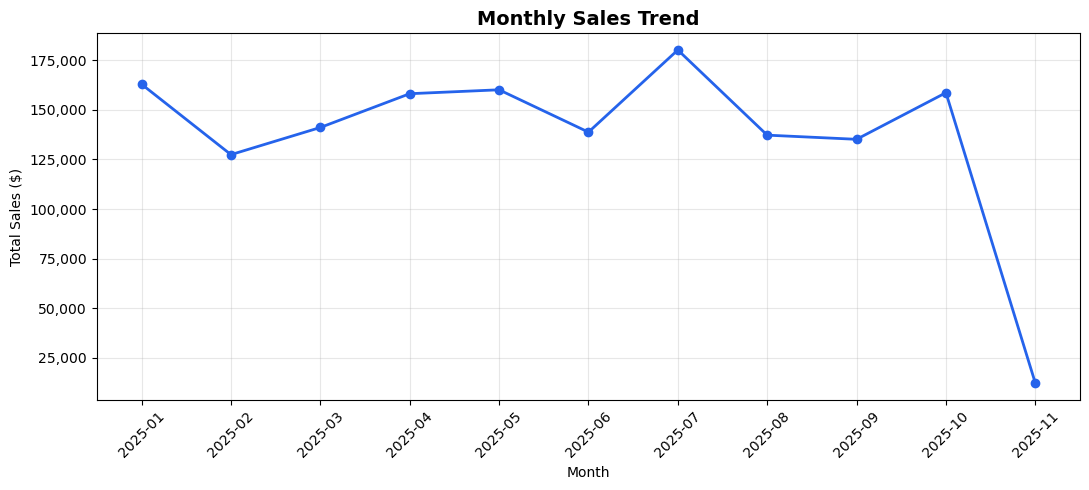

Order_YearMonth
2025-01    162944.58
2025-02    127450.66
2025-03    141141.78
2025-04    158166.28
2025-05    160141.26
2025-06    138792.41
2025-07    180208.16
2025-08    137276.89
2025-09    135177.50
2025-10    158668.22
2025-11     12285.24
Freq: M, Name: Total_Amount, dtype: float64


In [16]:
monthly_sales = df.groupby('Order_YearMonth')['Total_Amount'].sum().sort_index()

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(monthly_sales.index.astype(str), monthly_sales.values,
        marker='o', linewidth=2, color='#2563eb')
ax.set_title('Monthly Sales Trend', fontsize=14, fontweight='bold')
ax.set_xlabel('Month')
ax.set_ylabel('Total Sales ($)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print(monthly_sales)


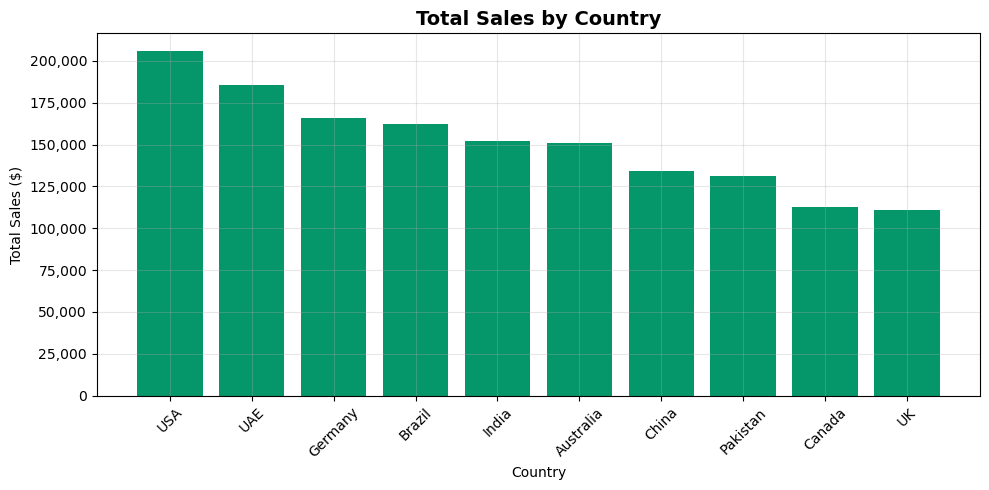

Country
USA          206117.53
UAE          185632.17
Germany      165844.33
Brazil       162245.30
India        152189.20
Australia    151043.18
China        134425.70
Pakistan     131479.73
Canada       112635.93
UK           110639.91
Name: Total_Amount, dtype: float64


In [17]:
# Sales by Country

country_sales = df.groupby('Country')['Total_Amount'].sum().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(country_sales.index, country_sales.values, color='#059669')
ax.set_title('Total Sales by Country', fontsize=14, fontweight='bold')
ax.set_xlabel('Country')
ax.set_ylabel('Total Sales ($)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print(country_sales)

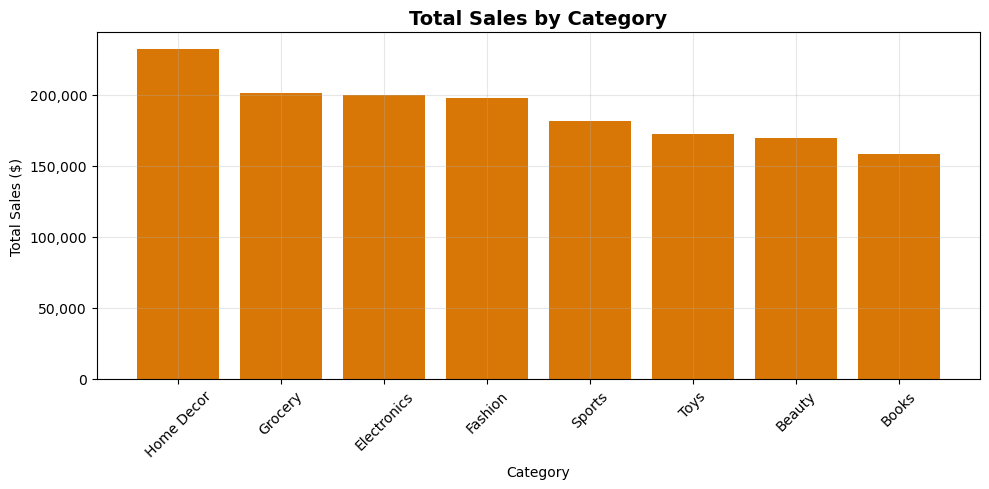

Category
Home Decor     232275.86
Grocery        201355.28
Electronics    199641.80
Fashion        197469.41
Sports         181433.90
Toys           172037.93
Beauty         169459.31
Books          158579.49
Name: Total_Amount, dtype: float64


In [18]:
# Sales by Category
category_sales = df.groupby('Category')['Total_Amount'].sum().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(category_sales.index, category_sales.values, color='#d97706')
ax.set_title('Total Sales by Category', fontsize=14, fontweight='bold')
ax.set_xlabel('Category')
ax.set_ylabel('Total Sales ($)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print(category_sales)


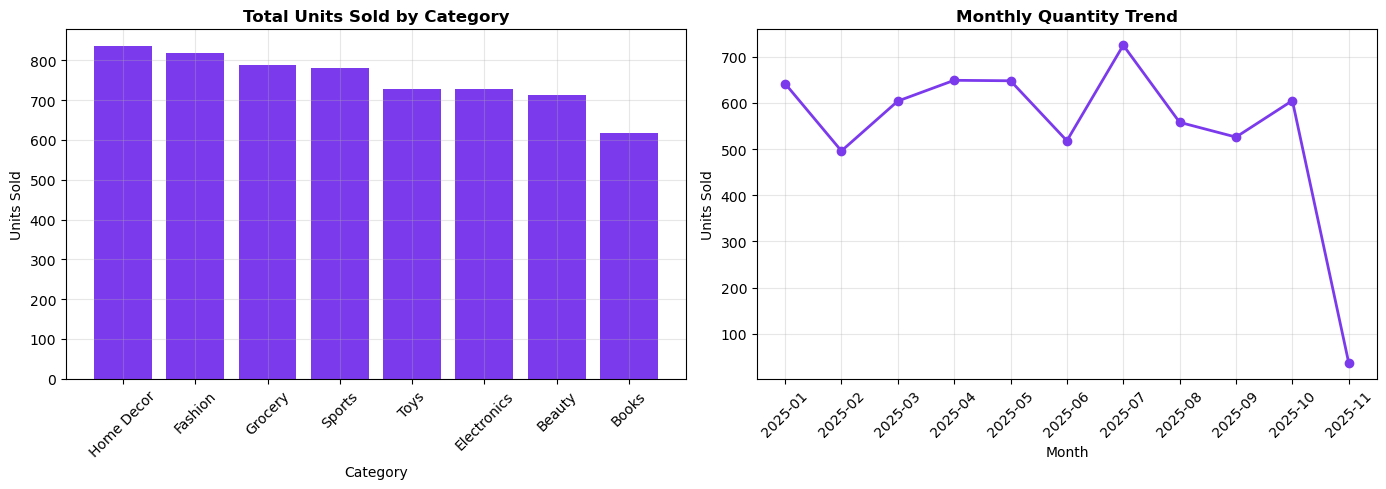

Category
Home Decor     836
Fashion        818
Grocery        789
Sports         780
Toys           728
Electronics    727
Beauty         713
Books          617
Name: Quantity, dtype: int64


In [19]:
# Quantity Analysis: units sold by category + monthly quantity trend

qty_by_category = df.groupby('Category')['Quantity'].sum().sort_values(ascending=False)
monthly_qty = df.groupby('Order_YearMonth')['Quantity'].sum().sort_index()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(qty_by_category.index, qty_by_category.values, color='#7c3aed')
axes[0].set_title('Total Units Sold by Category', fontweight='bold')
axes[0].set_xlabel('Category')
axes[0].set_ylabel('Units Sold')
axes[0].tick_params(axis='x', rotation=45)

axes[1].plot(monthly_qty.index.astype(str), monthly_qty.values,
             marker='o', linewidth=2, color='#7c3aed')
axes[1].set_title('Monthly Quantity Trend', fontweight='bold')
axes[1].set_xlabel('Month')
axes[1].set_ylabel('Units Sold')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

print(qty_by_category)


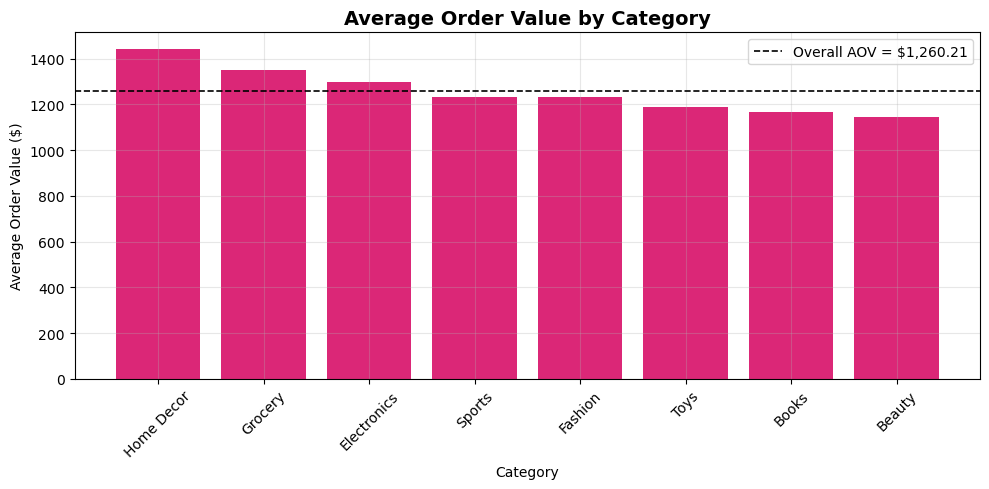

Overall Average Order Value: $1,260.21

Category
Home Decor     1442.707205
Grocery        1351.377718
Electronics    1296.375325
Sports         1234.244218
Fashion        1234.183812
Toys           1186.468483
Books          1166.025662
Beauty         1144.995338
Name: Total_Amount, dtype: float64


In [20]:
# Average Order Value — overall and by category

overall_aov = df['Total_Amount'].mean()
aov_by_category = df.groupby('Category')['Total_Amount'].mean().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(aov_by_category.index, aov_by_category.values, color='#db2777')
ax.axhline(overall_aov, color='black', linestyle='--', linewidth=1.2,
           label=f'Overall AOV = ${overall_aov:,.2f}')
ax.set_title('Average Order Value by Category', fontsize=14, fontweight='bold')
ax.set_xlabel('Category')
ax.set_ylabel('Average Order Value ($)')
ax.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print(f"Overall Average Order Value: ${overall_aov:,.2f}\n")
print(aov_by_category)

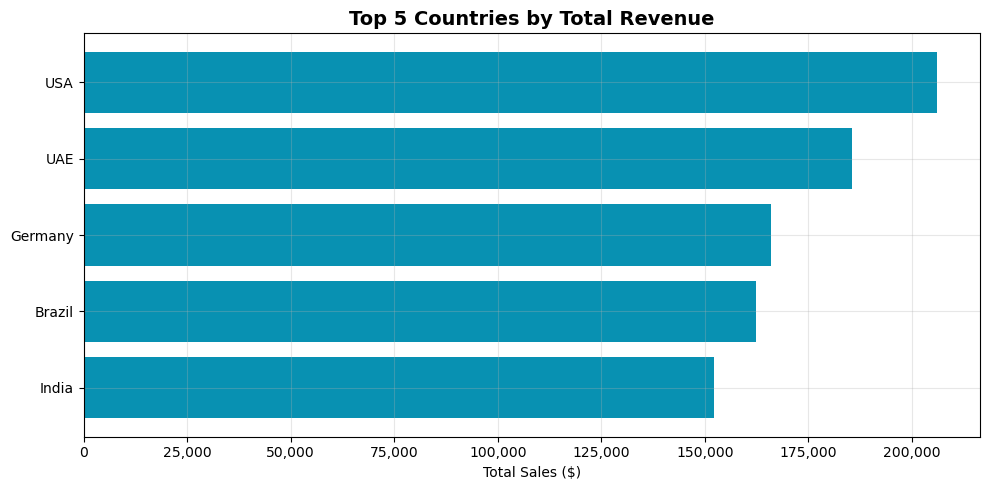

,Total_Sales,Order_Count,Avg_Order_Value
Country,,,
USA,206117.53,143,1441.38
UAE,185632.17,127,1461.67
Germany,165844.33,118,1405.46
Brazil,162245.30,123,1319.07
India,152189.20,130,1170.69
Australia,151043.18,120,1258.69
China,134425.70,108,1244.68
Pakistan,131479.73,111,1184.50
Canada,112635.93,116,971.00


In [21]:
# Top-Performing Countries — revenue vs. order volume

country_summary = df.groupby('Country').agg(
    Total_Sales=('Total_Amount', 'sum'),
    Order_Count=('Order_ID', 'count'),
    Avg_Order_Value=('Total_Amount', 'mean')
).sort_values('Total_Sales', ascending=False)

top_5_countries = country_summary.head(5)

fig, ax1 = plt.subplots(figsize=(10, 5))
ax1.barh(top_5_countries.index[::-1], top_5_countries['Total_Sales'][::-1], color='#0891b2')
ax1.set_title('Top 5 Countries by Total Revenue', fontsize=14, fontweight='bold')
ax1.set_xlabel('Total Sales ($)')
ax1.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
plt.tight_layout()
plt.show()

country_summary.round(2)


In [22]:
#Build the monthly time series and exclude any partial month

monthly_totals = df.groupby('Order_YearMonth')['Total_Amount'].sum().sort_index()
monthly_order_counts = df.groupby('Order_YearMonth').size()

# A month is treated as "partial" if its order count is far below the median

last_period = monthly_totals.index.max()
if monthly_order_counts.loc[last_period] < monthly_order_counts.median() * 0.5:
    print(f"Excluding partial month from training: {last_period} "
          f"({monthly_order_counts.loc[last_period]} orders vs. "
          f"median {monthly_order_counts.median():.0f})")
    monthly_totals_full = monthly_totals.drop(last_period)
else:
    monthly_totals_full = monthly_totals.copy()

ts = monthly_totals_full.reset_index()
ts.columns = ['YearMonth', 'Total_Sales']
ts['Time_Index'] = np.arange(1, len(ts) + 1)
ts


Excluding partial month from training: 2025-11 (5 orders vs. median 123)


,YearMonth,Total_Sales,Time_Index
0,2025-01,162944.58,1
1,2025-02,127450.66,2
2,2025-03,141141.78,3
3,2025-04,158166.28,4
4,2025-05,160141.26,5
5,2025-06,138792.41,6
6,2025-07,180208.16,7
7,2025-08,137276.89,8
8,2025-09,135177.50,9
9,2025-10,158668.22,10


In [23]:
#  Train / test split (time-ordered, not random — the last 2 months
# are held out as the test set so the split respects chronological order)

X = ts[['Time_Index']]
y = ts['Total_Sales']

test_size = 2
X_train, X_test = X.iloc[:-test_size], X.iloc[-test_size:]
y_train, y_test = y.iloc[:-test_size], y.iloc[-test_size:]

print(f"Training months: {len(X_train)}, Test months: {len(X_test)}")


Training months: 8, Test months: 2


In [24]:
#  Fit the Linear Regression model

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print(f"Model coefficient (monthly trend): {model.coef_[0]:,.2f}")
print(f"Model intercept: {model.intercept_:,.2f}")

Model coefficient (monthly trend): 940.96
Model intercept: 146,530.94


In [25]:
# Evaluation metrics

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"MAE  (Mean Absolute Error):      ${mae:,.2f}")
print(f"RMSE (Root Mean Squared Error):  ${rmse:,.2f}")
print(f"R2   (R-squared Score):          {r2:.4f}")

print(
    "\nNote: with only a handful of monthly data points available, these "
    "metrics are illustrative rather than production-grade. A real forecasting "
    "deployment would want at least 24-36 months of history and likely a "
    "dedicated time-series model (e.g. SARIMA or Prophet)."
)

MAE  (Mean Absolute Error):      $11,274.88
RMSE (Root Mean Squared Error):  $14,148.40
R2   (R-squared Score):          -0.4510

Note: with only a handful of monthly data points available, these metrics are illustrative rather than production-grade. A real forecasting deployment would want at least 24-36 months of history and likely a dedicated time-series model (e.g. SARIMA or Prophet).


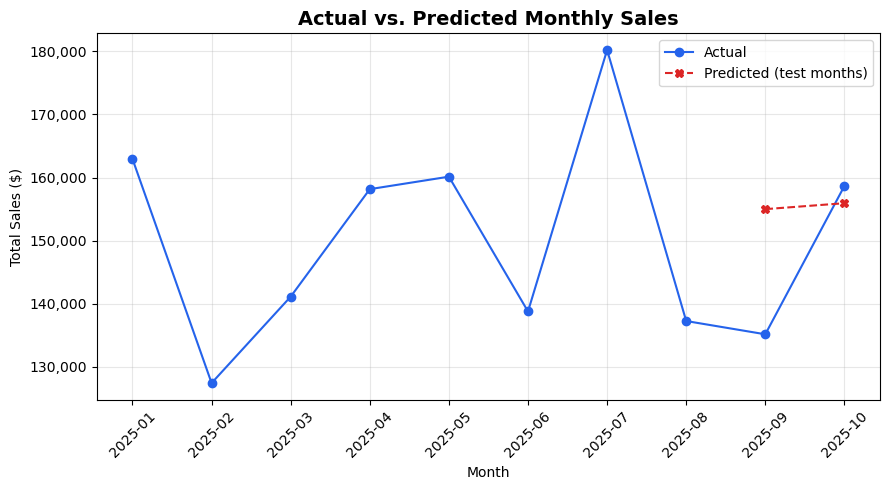

In [26]:
# Visualize actual vs. predicted test-period sales

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(ts['YearMonth'].astype(str), y, marker='o', label='Actual', color='#2563eb')
ax.plot(X_test['Time_Index'].map(lambda i: str(ts.loc[ts['Time_Index'] == i, 'YearMonth'].values[0])),
        y_pred, marker='X', linestyle='--', label='Predicted (test months)', color='#dc2626')
ax.set_title('Actual vs. Predicted Monthly Sales', fontsize=14, fontweight='bold')
ax.set_xlabel('Month')
ax.set_ylabel('Total Sales ($)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
ax.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [27]:
# Refit on all available (non-partial) months and forecast ahead

final_model = LinearRegression()
final_model.fit(X, y)

FUTURE_MONTHS = 3
last_time_index = ts['Time_Index'].max()
last_year_month = ts['YearMonth'].max()

future_time_index = pd.DataFrame(
    {'Time_Index': np.arange(last_time_index + 1, last_time_index + 1 + FUTURE_MONTHS)}
)
future_predictions = final_model.predict(future_time_index)

future_periods = [last_year_month + i for i in range(1, FUTURE_MONTHS + 1)]

forecast_df = pd.DataFrame({
    'YearMonth': [str(p) for p in future_periods],
    'Predicted_Total_Amount': np.round(future_predictions, 2)
})

forecast_df


,YearMonth,Predicted_Total_Amount
0,2025-11,151365.21
1,2025-12,151614.01
2,2026-01,151862.82


In [28]:
# Export forecast to CSV

OUTPUT_PATH = "sales_forecast.csv"
forecast_df.to_csv(OUTPUT_PATH, index=False)
print(f"Forecast saved to '{OUTPUT_PATH}'")


Forecast saved to 'sales_forecast.csv'
